# 1. Extração de Entidades Nomeadas

Este trecho realiza o pré-processamento linguístico de um texto em português utilizando a biblioteca spaCy, com foco na extração de entidades nomeadas e na análise de suas relações sintáticas.

Após o download e carregamento do modelo pt_core_news_lg, o texto de exemplo é analisado, identificando entidades como organizações e localidades (por exemplo, "Apple" e "Rio de Janeiro").

Para cada entidade, o código imprime informações relevantes: a **categoria da entidade**, seu **token central** na árvore de dependências, sua **função sintática** (como sujeito ou objeto), e a **palavra à qual está subordinada**.

Essa análise permite compreender não apenas quem ou o que está sendo mencionado no texto, mas também como essas entidades se relacionam gramaticalmente dentro da sentença, o que é essencial para aplicações como análise semântica, extração de informação e compreensão textual automatizada.

In [ ]:
import pandas as pd
import spacy
from collections import Counter


!python -m spacy download pt_core_news_lg

# Carrega o modelo em português
nlp = spacy.load("pt_core_news_lg")



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 1.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Texto de exemplo com possíveis ambiguidades
texto = "A Apple lançou um novo produto no Rio de Janeiro, mas os consumidores reclamaram do preço."

# Processamento do texto
doc = nlp(texto)


In [ ]:
print("=== ENTIDADES NOMEADAS + DEPENDÊNCIAS ===\n")
for ent in doc.ents:
    token_central = ent.root  # Palavra central da entidade
    print(f"Entidade: {ent.text}")
    print(f" - Label: {ent.label_}")
    print(f" - Palavra base: {token_central.text}")
    print(f" - Função sintática: {token_central.dep_}")
    print(f" - Cabeça gramatical: {token_central.head.text}")
    print()


=== ENTIDADES NOMEADAS + DEPENDÊNCIAS ===

Entidade: Apple
 - Label: ORG
 - Palavra base: Apple
 - Função sintática: nsubj
 - Cabeça gramatical: lançou

Entidade: Rio de Janeiro
 - Label: LOC
 - Palavra base: Rio
 - Função sintática: obl
 - Cabeça gramatical: lançou



# 2. Análise de Opiniões e Polaridade (básico)

O trecho abaixo tem como objetivo inicial identificar indícios de opiniões ou avaliações subjetivas no texto, focando em dois elementos linguísticos: **adjetivos** e **conectores adversativos**.

Os adjetivos (**token.pos_ == "ADJ"**) são listados juntamente com o termo ao qual estão sintaticamente ligados (**token.head**), permitindo observar a quem ou a quê a qualificação se refere. Isso é útil para inferir juízos de valor (positivos ou negativos) no discurso.

Em seguida, o código busca por conectores adversativos como “mas”, “porém” e “contudo”, que frequentemente introduzem mudanças de polaridade ou nuanças argumentativas, podendo inverter ou mitigar o sentimento previamente expresso. A combinação desses elementos é fundamental em tarefas de análise de sentimentos e interpretação pragmática de enunciados.

In [ ]:
print("=== OPINIÕES / POLARIDADE ===\n")
for token in doc:
    if token.pos_ == "ADJ":
        print(f"Adjetivo: {token.text} → relacionado a: {token.head.text} (função: {token.dep_})")

# Verifica conectores adversativos
for token in doc:
    if token.text.lower() in ["mas", "porém", "contudo"]:
        print(f"Conector adversativo identificado: '{token.text}' (pode inverter ou moderar o sentimento)")


=== OPINIÕES / POLARIDADE ===

Adjetivo: novo → relacionado a: produto (função: amod)
Conector adversativo identificado: 'mas' (pode inverter ou moderar o sentimento)


# 3. Extração de Atributos Linguísticos Agregados

Este bloco de código implementa um processo de extração de atributos linguísticos estruturados a partir de uma lista de documentos textuais. A função extrair_features() aplica o modelo SpaCy a cada texto, gerando um conjunto de features agregadas que descrevem propriedades gramaticais e semânticas dos documentos. Especificamente, são computadas:

* A contagem total de tokens e de entidades nomeadas;

* A frequência de algumas classes gramaticais relevantes (NOUN, VERB, ADJ, PROPN);

* A frequência de tipos específicos de entidades (PER para pessoas, ORG para organizações, LOC para localidades);

* A contagem de funções sintáticas centrais, como sujeito (nsubj), objeto (obj), modificador adjetival (amod) e adverbial (advmod).

Cada conjunto de atributos é armazenado como um dicionário, e os resultados para todos os textos são consolidados em um DataFrame do pandas. Esse procedimento transforma dados linguísticos brutos em uma representação vetorial tabular, útil para análises quantitativas, visualização e modelagem preditiva com algoritmos de aprendizado de máquina.

In [ ]:
documentos = [
    "A Apple lançou um novo produto em São Paulo, mas os consumidores reclamaram do preço.",
    "O presidente da empresa visitou a unidade de produção no Rio de Janeiro.",
    "Clientes elogiaram a qualidade do serviço prestado pela companhia aérea Azul.",
    "João dos Santos é um consumidor feliz de produtos Apple.",
    "O ator Michael Fassbender interpretou Steve Jobs em um filme sobre a Apple."
]

# Função para extrair atributos agregados
def extrair_features(doc_text, doc_id):
    doc = nlp(doc_text)

    pos_counts = Counter([token.pos_ for token in doc])
    ent_types = Counter([ent.label_ for ent in doc.ents])
    dep_counts = Counter([token.dep_ for token in doc])

    features = {
        "documento_id": doc_id,
        "texto_original": doc_text,
        "n_tokens": len(doc),
        "n_entidades": len(doc.ents),
    }

    # Agrega POS tags
    for tag in ["NOUN", "VERB", "ADJ", "PROPN"]:
        features[f"qtde_{tag}"] = pos_counts.get(tag, 0)

    # Agrega tipos de entidades
    for ent in ["PER", "ORG", "LOC"]:
        features[f"qtde_{ent}"] = ent_types.get(ent, 0)

    # Agrega relações de dependência sintática mais comuns
    for dep in ["nsubj", "obj", "amod", "advmod"]:
        features[f"qtde_{dep}"] = dep_counts.get(dep, 0)

    return features

# Aplica a função a todos os documentos
dados_agregados = [extrair_features(texto, idx) for idx, texto in enumerate(documentos)]

# Cria o DataFrame
df_doc_features = pd.DataFrame(dados_agregados)
df_doc_features

,documento_id,texto_original,n_tokens,n_entidades,qtde_NOUN,qtde_VERB,qtde_ADJ,qtde_PROPN,qtde_PER,qtde_ORG,qtde_LOC,qtde_nsubj,qtde_obj,qtde_amod,qtde_advmod
0,0,"A Apple lançou um novo produto em São Paulo, m...",17,2,3,2,1,3,0,1,1,2,2,1,0
1,1,O presidente da empresa visitou a unidade de p...,14,1,4,1,0,2,0,0,1,1,1,0,0
2,2,Clientes elogiaram a qualidade do serviço pres...,12,2,4,2,2,0,0,1,1,1,1,2,0
3,3,João dos Santos é um consumidor feliz de produ...,11,2,2,0,1,3,1,1,0,1,0,1,0
4,4,O ator Michael Fassbender interpretou Steve Jo...,14,3,2,1,0,5,2,1,0,1,1,0,0


In [ ]:
frases_dados = []

for doc_id, texto in enumerate(documentos):
    doc = nlp(texto)
    for sent_id, sent in enumerate(doc.sents):
        # Lista de substantivos e nomes próprios
        tokens = [token.lemma_.lower() for token in sent if token.pos_ in ["NOUN", "PROPN"] and not token.is_stop]
        entidades = [ent.text for ent in sent.ents]

        frases_dados.append({
            "doc_id": doc_id + 1,
            "frase_id": sent_id + 1,
            "frase": sent.text.strip(),
            "substantivos/nomes_próprios": tokens,
            "entidades_nomeadas": entidades
        })

# Exibe como DataFrame
df_frases = pd.DataFrame(frases_dados)
df_frases

,doc_id,frase_id,frase,substantivos/nomes_próprios,entidades_nomeadas
0,1,1,"A Apple lançou um novo produto em São Paulo, m...","[apple, produto, paulo, consumidor, preço]","[Apple, São Paulo]"
1,2,1,O presidente da empresa visitou a unidade de p...,"[presidente, empresa, unidade, produção, rio, ...",[Rio de Janeiro]
2,3,1,Clientes elogiaram a qualidade do serviço pres...,"[cliente, qualidade, serviço, companhia]","[Clientes, Azul]"
3,4,1,João dos Santos é um consumidor feliz de produ...,"[joão, santos, consumidor, produto, apple]","[João dos Santos, Apple]"
4,5,1,O ator Michael Fassbender interpretou Steve Jo...,"[ator, michael, fassbender, steve, jobs, filme...","[Michael Fassbender, Steve Jobs, Apple]"


# 4. Análise de Sentimentos com Transformers

Neste trecho, é realizada uma análise de sentimentos baseada em modelos pré-treinados da biblioteca **transformers**, desenvolvida pela Hugging Face. Inicialmente, instala-se as dependências necessárias (transformers e torch) e, em seguida, é carregado o **modelo nlptown/bert-base-multilingual-uncased-sentiment** por meio de um pipeline de tarefa do tipo "sentiment-analysis". Esse modelo é multilíngue e classifica textos com base em uma **escala ordinal de 1 a 5 estrelas**, onde 1 indica avaliação negativa e 5, positiva.

O texto fornecido é uma resenha com aspectos positivos e negativos sobre um produto. O pipeline processa o texto completo e retorna uma classificação geral de sentimento, refletindo a média emocional do conteúdo. No exemplo exibido, o resultado é '2 stars', com uma probabilidade associada, indicando uma avaliação predominantemente negativa ou decepcionada. Esse tipo de abordagem é útil para tarefas de **mineração de opinião**, **monitoramento de reputação de marca** ou c**lassificação automática de resenhas**.

In [ ]:
!pip install transformers
!pip install torch
from transformers import pipeline

In [ ]:
texto = """
Na Unidade de Saúde não havia filas e o ambiente estava organizado e limpo.

A equipe de enfermagem foi gentil e atenciosa. Porém, o Dr. Maiko atrasou.

Não havia o remédio que eu necessito, e ninguém soube dizer quando chega.
"""

doc = nlp(texto)

In [ ]:
# Cria o pipeline de análise de sentimentos
sent_pipeline = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

# Resultado global
resultado_doc = sent_pipeline(texto)
print("********")
print("Resultado (documento inteiro):", resultado_doc)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

********
Resultado (documento inteiro): [{'label': '2 stars', 'score': 0.5215415358543396}]


# 5. Análise de Sentimentos por Sentença com Visualização

Este trecho realiza uma **análise de sentimentos com granularidade sentencial**, aplicando o modelo bert-base-multilingual-uncased-sentiment a cada sentença do texto.

Inicialmente, o texto processado pelo spaCy é **segmentado em sentenças** (doc.sents). Cada sentença é então **analisada individualmente** pelo pipeline de sentimentos, retornando uma classificação ordinal (1 a 5 estrelas) e um score de confiança.

Os resultados são armazenados em uma lista e visualizados de duas formas complementares:

* Gráfico de linha: representa a variação da polaridade ao longo do texto, evidenciando como o sentimento flutua entre as sentenças, o que é útil para detectar zonas de insatisfação ou entusiasmo ao longo da narrativa.

* Renderização HTML com cores: cada sentença é destacada com uma cor de fundo proporcional à sua polaridade (vermelho para avaliações negativas, verde para positivas). Essa visualização facilita a leitura qualitativa, permitindo perceber rapidamente a distribuição emocional do texto.

Essa abordagem oferece uma análise mais refinada que a avaliação global, sendo especialmente útil para resenhas longas, feedbacks mistos ou diagnósticos de discurso em contextos como marketing, suporte ao cliente e análise textual qualitativa.

In [ ]:
# Extrai sentenças
sentencas = [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 0]

# Aplica análise por sentença
resultados_sentencas = []
for sent in sentencas:
    resultado = sent_pipeline(sent)[0]
    resultados_sentencas.append((sent, resultado['label'], resultado['score']))

# Exibe os resultados
for sent, label, score in resultados_sentencas:
    print(f"[{label} - Confiança: {score:.2f}] → {sent}")

[4 stars - Confiança: 0.39] → Na Unidade de Saúde não havia filas e o ambiente estava organizado e limpo.
[4 stars - Confiança: 0.49] → A equipe de enfermagem foi gentil e atenciosa.
[3 stars - Confiança: 0.48] → Porém, o Dr. Maiko atrasou.
[1 star - Confiança: 0.49] → Não havia o remédio que eu necessito, e ninguém soube dizer quando chega.


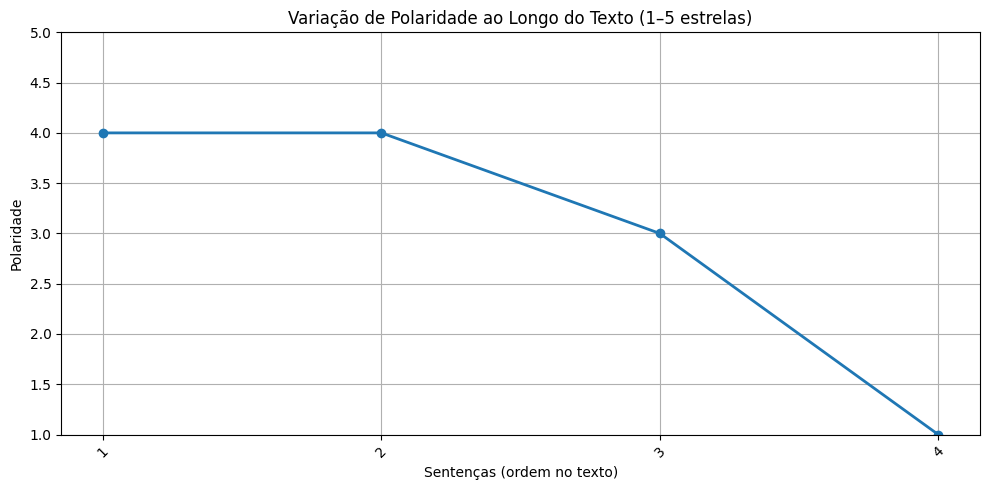

In [ ]:
import matplotlib.pyplot as plt

# Mapeia label textual para valor numérico
def label_para_numero(label):
    return int(label[0])  # label = "5 stars" → 5

# Prepara dados
valores_polaridade = [label_para_numero(label) for _, label, _ in resultados_sentencas]
sentencas_plot = [f"{i+1}" for i in range(len(valores_polaridade))]

# Plotagem
plt.figure(figsize=(10, 5))
plt.plot(sentencas_plot, valores_polaridade, marker='o', linestyle='-', linewidth=2)
plt.title("Variação de Polaridade ao Longo do Texto (1–5 estrelas)")
plt.xlabel("Sentenças (ordem no texto)")
plt.ylabel("Polaridade")
plt.ylim(1, 5)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
from IPython.core.display import display, HTML

# Define mapa de estrelas para cores
def cor_por_polaridade(estrelas):
    cores = {
        1: "#d73027",  # vermelho escuro
        2: "#fc8d59",  # laranja
        3: "#cccccc",  # cinza claro
        4: "#91cf60",  # verde claro
        5: "#1a9850",  # verde forte
    }
    return cores.get(estrelas, "#ffffff")

# Gera HTML com sentenças coloridas
sentencas_html = []
for sent, label, score in resultados_sentencas:
    estrela = int(label[0])
    cor = cor_por_polaridade(estrela)
    html_sent = f"<span style='background-color:{cor}; padding: 2px 4px; border-radius: 4px; display:inline-block; margin:2px'>{sent}</span>"
    sentencas_html.append(html_sent)

# Exibe o resultado formatado
display(HTML("<p style='line-height:1.8em'>" + " ".join(sentencas_html) + "</p>"))
